## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/simple_water_bodies_mapping-swbm/
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
Author of the original script: Mohor Gartner
Conversion: Development Seed (openEO-UDP project)


# Simple Water Bodies' Mapping (SWBM) with OpenEO

This notebook converts the Sentinel Hub *Simple Water Bodies' Mapping* (SWBM) evalscript by Mohor Gartner into an openEO User-Defined Process. SWBM detects surface water in Sentinel-2 L2A imagery using an **OR-ensemble of three normalized-difference indices** — MNDWI, NDWI and SWI — with calibrated thresholds. Water pixels are rendered blue and non-water pixels are rendered as 2× true colour.

## Overview

1. Connect to an OpenEO backend.
2. Load the five Sentinel-2 bands required by the three SWBM indices.
3. Compute MNDWI / NDWI / SWI and combine them with OR logic to mask water.
4. Render water pixels blue, non-water pixels as 2× true colour.
5. Export the result as a parameterized openEO process graph.

The Sentinel-2 example locations from the original script (Lake of Sainte-Croix, Oroville Dam) are provided as ready-to-run parameter sets. The Landsat 8/9 variant of the script (Kandhkot, Furnace Creek) is tracked in a follow-up issue.

## Scientific Background

Water has very low reflectance in the NIR and SWIR bands while vegetation and soil reflect strongly there. Normalized-difference indices that contrast a green band with NIR or SWIR therefore produce high positive values over water and negative values over land.

| Index | Formula | Default threshold | Reference |
|-------|---------|-------------------|-----------|
| MNDWI | `(B03 − B11) / (B03 + B11)` | `0.10` | Xu, 2006 |
| NDWI  | `(B03 − B08) / (B03 + B08)` | `0.20` | McFeeters, 1996 |
| SWI   | `1 / sqrt(B02 − B11)` | `0.03` | Malahlela, 2016 |

**Water mask (OR-logic, verbatim from the evalscript):**

```
is_water = (MNDWI > MNDWI_thr) || (NDWI > NDWI_thr) || (SWI > SWI_thr)
```

**Calibration guidance from the original script:** run the script on a representative scene and inspect the histogram of each index. There should typically be two peaks (water and non-water); the threshold sits in the valley between them. Repeat on (a) a mixed scene, (b) a non-water-only scene and (c) a water-only scene to refine the three thresholds.

**Cloud handling:** this UDP filters scenes by `eo:cloud_cover`. The original evalscript additionally masks Sen2Cor SCL classes 8 and 9 (cloud medium/high probability) at pixel level — a scene-level cloud filter is used here for simplicity; refine if your AOI is small relative to the tile.

## Import Libraries

In [14]:
import json
import os

import matplotlib.pyplot as plt
from PIL import Image
from openeo.api.process import Parameter
from openeo.processes import array_create, if_, or_, power

from openeo_udp import ParameterManager

## Load Parameters and Connect to OpenEO Backend

In [15]:
param_manager = ParameterManager('swbm.params.py')
param_manager.print_options("Simple Water Bodies' Mapping (SWBM)")

Available parameter sets for Simple Water Bodies' Mapping (SWBM):
  1. lake_sainte_croix: Lake of Sainte-Croix, France
  2. oroville_dam: Oroville Dam, California, USA
  3. aral_sea: Aral Sea, Kazakhstan
  4. poyang_lake: Poyang Lake, China

Available OpenEO endpoints:
  1. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo
  2. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  3. ds_development: https://openeo.ds.io/
  4. localhost_dev: http://localhost:8082/

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [ ]:
# selection_widget = param_manager.interactive_parameter_selection()

print("\nAlternative (programmatic):")
print("   connection, params = param_manager.quick_connect('lake_sainte_croix', 'copernicus_dataspace')")


Alternative (programmatic):
   connection, params = param_manager.quick_connect('lake_sainte_croix', 'localhost_dev')


## Define UDP Runtime Parameters

The three thresholds are exposed on the final UDP so the same graph can be calibrated per scene without recompiling. Defaults match the Sentinel Hub evalscript.

In [17]:
mndwi_thr = Parameter.number(
    "MNDWI_thr",
    description="MNDWI water threshold (default 0.1 per Sentinel Hub evalscript)",
    default=0.1,
)

ndwi_thr = Parameter.number(
    "NDWI_thr",
    description="NDWI water threshold (default 0.2 per Sentinel Hub evalscript)",
    default=0.2,
)

swi_thr = Parameter.number(
    "SWI_thr",
    description="SWI water threshold (default 0.03 per Sentinel Hub evalscript)",
    default=0.03,
)

## Load Sentinel-2 Data

The five bands below cover all three SWBM indices:
- **B02** (490 nm): SWI numerator argument and true-colour blue
- **B03** (560 nm): MNDWI / NDWI numerator (green) and true-colour green
- **B04** (665 nm): true-colour red
- **B08** (842 nm): NDWI denominator (NIR)
- **B11** (1610 nm): MNDWI / SWI denominator (SWIR1)

In [ ]:
# connection, current_params = selection_widget()
connection, current_params = param_manager.quick_connect('lake_sainte_croix', 'copernicus_dataspace')

s2cube = connection.load_collection(
    current_params["collection"].default,
    temporal_extent=current_params["time"].default,
    spatial_extent=current_params["bounding_box"].default,
    bands=current_params["bands"].default,
    properties={
        "eo:cloud_cover": lambda x: x <= current_params["cloud_cover"].default,
    },
)

s2cube = s2cube.reduce_dimension(dimension="t", reducer="first")

🔄 Connecting to localhost_dev...
📍 Using parameter set: lake_sainte_croix
✅ Successfully connected to localhost_dev
✅ Parameters loaded and mapped for: Lake of Sainte-Croix, France
🔄 Parameters mapped for endpoint localhost_dev:
  bands: ['B02', 'B03', 'B04', 'B08', 'B11'] -> ['B02_10m', 'B03_10m', 'B04_10m', 'B08_10m', 'B11_20m']
  collection: SENTINEL2_L2A -> sentinel-2-l2a


## SWBM Visualization Function

The function below:
1. Scales the five S2 bands to TOA reflectance (`/10000`).
2. Computes MNDWI, NDWI and SWI.
3. Combines them with OR logic to produce the water mask.
4. Renders water pixels as solid blue and non-water pixels as 2× true colour, matching the Sentinel Hub script.

In [19]:
def swbm_visualization(data, context):
    """Apply the SWBM water-detection visualization.

    Input data array order: [B02, B03, B04, B08, B11].
    Context array order:    [MNDWI_thr, NDWI_thr, SWI_thr].

    Top-level openEO Parameter references are not visible inside a callback's
    scope; thresholds are plumbed in via the `context` argument of
    apply_dimension. See openEO spec for `apply_dimension.context`.
    """
    B02, B03, B04, B08, B11 = data[0], data[1], data[2], data[3], data[4]
    MNDWI_thr, NDWI_thr, SWI_thr = context[0], context[1], context[2]

    # Scale DN -> reflectance (Sentinel-2 L2A scale factor 10000).
    B02 = B02 / 10000
    B03 = B03 / 10000
    B04 = B04 / 10000
    B08 = B08 / 10000
    B11 = B11 / 10000

    MNDWI = (B03 - B11) / (B03 + B11)
    NDWI = (B03 - B08) / (B03 + B08)
    # SWI = 1 / sqrt(B02 - B11); only defined where B02 > B11 (typical over water).
    SWI = 1 / power(B02 - B11, 0.5)

    is_water = or_(
        or_(MNDWI > MNDWI_thr, NDWI > NDWI_thr),
        SWI > SWI_thr,
    )

    # Evalscript: water -> [0, 0, 2], land -> [r*2, g*2, b*2].
    # We compress to [0, 1] because linear_scale_range maps to [0, 255].
    water_color = array_create([0, 0, 1])
    land_color = array_create([B04 * 2, B03 * 2, B02 * 2])

    return if_(is_water, water_color, land_color)

## Apply the Algorithm

For the synchronous preview the thresholds are resolved to their defaults; the UDP export below keeps them as Parameter references.

In [20]:
swbm_image = s2cube.apply_dimension(
    dimension="spectral",
    process=swbm_visualization,
    context=[0.1, 0.2, 0.03],
)
swbm_image = swbm_image.linear_scale_range(
    input_min=0, input_max=1, output_min=0, output_max=255
)

In [21]:
print(swbm_image.to_json())

{
  "process_graph": {
    "loadcollection1": {
      "process_id": "load_collection",
      "arguments": {
        "bands": [
          "B02_10m",
          "B03_10m",
          "B04_10m",
          "B08_10m",
          "B11_20m"
        ],
        "id": "sentinel-2-l2a",
        "properties": {
          "eo:cloud_cover": {
            "process_graph": {
              "lte1": {
                "process_id": "lte",
                "arguments": {
                  "x": {
                    "from_parameter": "value"
                  },
                  "y": 22
                },
                "result": true
              }
            }
          }
        },
        "spatial_extent": {
          "west": 6.1,
          "south": 43.72,
          "east": 6.27,
          "north": 43.82
        },
        "temporal_extent": [
          "2022-08-01",
          "2022-08-31"
        ]
      }
    },
    "reducedimension1": {
      "process_id": "reduce_dimension",
      "arguments": {
   

## Download and Visualize

Running SWBM with default thresholds on the selected location.

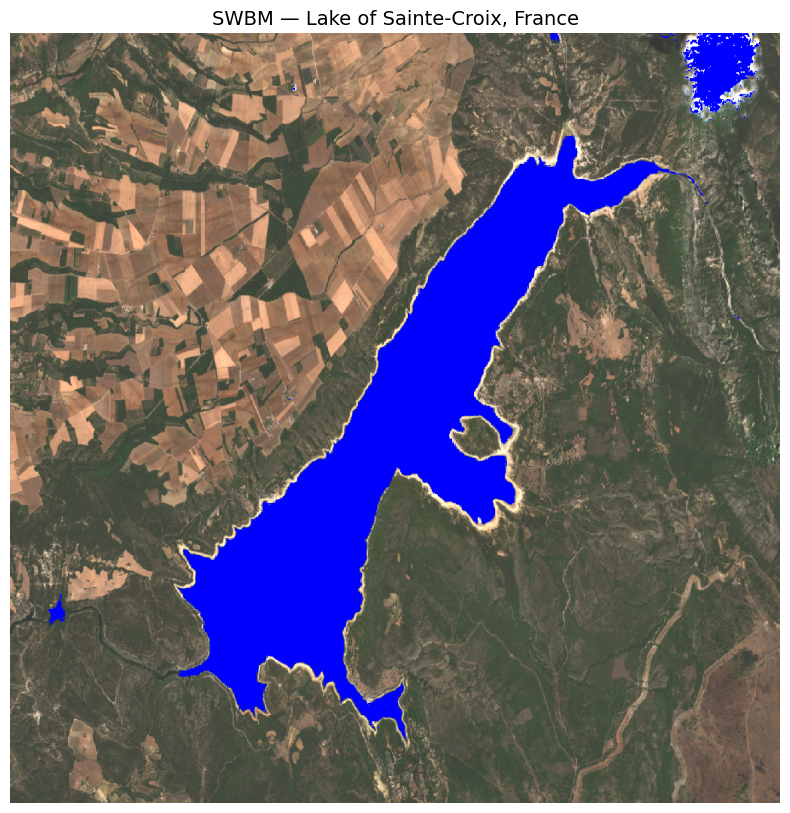

In [22]:
filename = f"swbm_{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.png"

connection.download(
    {
        "process_graph": swbm_image.save_result("PNG").flat_graph(),
        "parameters": [
            current_params["time"].to_dict(),
            current_params["bounding_box"].to_dict(),
            current_params["bands"].to_dict(),
            mndwi_thr.to_dict(),
            ndwi_thr.to_dict(),
            swi_thr.to_dict(),
        ],
    },
    filename,
)

img = Image.open(filename)
plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.title(f"SWBM \u2014 {current_params['location_name']}", fontsize=14)
plt.axis("off")
plt.show()

## Export Process Graph

The exported JSON is the parameterized UDP: three threshold parameters plus the standard spatial / temporal / bands / cloud-cover parameters.

In [23]:
udp_image = s2cube.apply_dimension(
    dimension="spectral",
    process=swbm_visualization,
    context=[mndwi_thr, ndwi_thr, swi_thr],
).linear_scale_range(input_min=0, input_max=1, output_min=0, output_max=255)

udp = {
    "id": "swbm",
    "summary": "Simple Water Bodies' Mapping (SWBM)",
    "description": (
        "Detects surface water in Sentinel-2 L2A scenes using an OR-ensemble "
        "of three normalized-difference indices (MNDWI, NDWI, SWI). Water "
        "pixels render blue; non-water pixels render as 2x true colour. "
        "Thresholds default to the Sentinel Hub evalscript values "
        "(MNDWI_thr=0.1, NDWI_thr=0.2, SWI_thr=0.03) and may be calibrated "
        "per scene using the histogram inspection procedure described in "
        "the original script."
    ),
    "parameters": [
        current_params["time"].to_dict(),
        current_params["bounding_box"].to_dict(),
        current_params["bands"].to_dict(),
        current_params["cloud_cover"].to_dict(),
        mndwi_thr.to_dict(),
        ndwi_thr.to_dict(),
        swi_thr.to_dict(),
    ],
    "process_graph": udp_image.save_result("PNG").flat_graph(),
}

graph_path = "../../../../graphs/sentinel/sentinel-2/marine_and_water_bodies/swbm.json"
os.makedirs(os.path.dirname(graph_path), exist_ok=True)
with open(graph_path, "w") as f:
    json.dump(udp, f, indent=2)

print(f"Process graph exported to {graph_path}")
print(f"Process ID: {udp['id']}")

Process graph exported to ../../../../graphs/sentinel/sentinel-2/marine_and_water_bodies/swbm.json
Process ID: swbm


## Threshold Tuning Guide

| Threshold | Default | When to raise | When to lower |
|-----------|---------|---------------|---------------|
| `MNDWI_thr` | `0.10` | Built-up shadows are being classified as water | Turbid or shallow water is being missed |
| `NDWI_thr`  | `0.20` | Wet vegetation is being classified as water | Sediment-laden water is being missed |
| `SWI_thr`   | `0.03` | False positives over very dark land (lava, burned scars) | Shallow / mixed-pixel water is being missed |

Per the original author's guidance, run the UDP once with the defaults, inspect the histogram of each index over your AOI, and pick a threshold that sits in the valley between the water peak (right) and the non-water peak (left).

## Limitations

- Scene-level `eo:cloud_cover` filtering does not catch isolated cloud over the AOI; for small AOIs prefer SCL-based pixel masking.
- Cloud shadow and topographic shadow can mimic water in the MNDWI / NDWI channels.
- The SWI term is undefined where `B02 ≤ B11` (typical over bright land); this manifests as NaN that does not contribute to the OR-mask.
- The 2× true-colour stretch is a visualisation choice, not a radiometric correction.

## Attribution and References

**Original evalscript:** [Simple Water Bodies' Mapping (SWBM)](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/simple_water_bodies_mapping-swbm/)

**Author of the original script:** Mohor Gartner.

**Source repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

### Scientific references

- McFeeters, S.K., 1996. The use of the Normalized Difference Water Index (NDWI) in the delineation of open water features. *Int. J. Remote Sens.* 17, 1425–1432. <https://doi.org/10.1080/01431169608948714>
- Xu, H., 2006. Modification of normalised difference water index (NDWI) to enhance open water features in remotely sensed imagery. *Int. J. Remote Sens.* 27, 3025–3033. <https://doi.org/10.1080/01431160600589179>
- Malahlela, O.E., 2016. Inland waterbody mapping: towards improving discrimination and extraction of inland surface water features. *Int. J. Remote Sens.* 37, 4574–4589. <https://doi.org/10.1080/01431161.2016.1217441>

### License

CC-BY-SA 4.0. Please cite as: *Simple Water Bodies' Mapping (SWBM), open code for EO Browser by Mohor Gartner*.